# Task
Fetch stock data for a user-specified Taiwanese stock ticker for the past 10 years and save it to a CSV file.

## 安裝必要的套件

### Subtask:
安裝用於股票資料抓取的 `yfinance` 套件。


**Reasoning**:
The subtask requires installing the `yfinance` package, so I will use `pip` to install it.



In [1]:
## pip install yfinance

## 匯入所需套件

### Subtask:
匯入 `yfinance` 和 `pandas` 套件，以便進行資料抓取與處理。


**Reasoning**:
The subtask requires importing `yfinance` and `pandas` packages. I will create a code block to import these packages, aliasing `pandas` as `pd`.



In [2]:
CUDA_VISIBLE_DEVICES=1
import yfinance as yf
import pandas as pd
print("yfinance and pandas packages imported successfully.")

yfinance and pandas packages imported successfully.


## 定義抓取股票資料的函數

### Subtask:
建立一個函數，輸入股票代碼，抓取近十年的每日收盤價、最高價、最低價等資訊。


**Reasoning**:
The subtask requires defining a function to fetch stock data for the past 10 years. I will create a Python function `fetch_stock_data` that takes a ticker as input, calculates the start and end dates, uses `yfinance` to download the historical data, and returns a pandas DataFrame.



In [3]:
from datetime import datetime, timedelta

def fetch_stock_data(ticker):
    """
    Fetches historical stock data for a given ticker for the past 10 years.

    Args:
        ticker (str): The stock ticker symbol (e.g., '2330.TW' for TSMC).

    Returns:
        pandas.DataFrame: Historical stock data including Open, High, Low, Close, Volume, etc.
                          Returns an empty DataFrame if data fetching fails.
    """
    end_date = datetime.now()
    start_date = end_date - timedelta(days=10*365) # Approximate 10 years

    try:
        stock = yf.Ticker(ticker)
        # Fetch daily data for the specified period
        data = stock.history(start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'), interval='1d')
        if data.empty:
            print(f"No data found for {ticker} in the last 10 years.")
        else:
            print(f"Successfully fetched data for {ticker} from {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}.")
        return data
    except Exception as e:
        print(f"Error fetching data for {ticker}: {e}")
        return pd.DataFrame() # Return an empty DataFrame on error

print("fetch_stock_data function defined.")

fetch_stock_data function defined.


## 讓使用者輸入股票代碼

### Subtask:
提示使用者輸入要查詢的台灣股票代碼。


**Reasoning**:
The subtask requires prompting the user for a Taiwanese stock ticker and reminding them about the '.TW' suffix. I will use the `input()` function to get the ticker from the user and store it in a variable.



In [4]:
# @title
ticker_symbol = input("請輸入要查詢的台灣股票代碼 (例如 '2330.TW'，請務必加上 '.TW' 後綴): ")
print(f"您輸入的股票代碼是: {ticker_symbol}")

您輸入的股票代碼是: 2330.TW


In [5]:
stock_data = fetch_stock_data(ticker_symbol)

if not stock_data.empty:
    filename = f"{ticker_symbol.replace('.TW', '')}_stock_data.csv"
    stock_data.to_csv(filename, index=True) # index=True to save the Date as a column
    print(f"股票資料已成功儲存為 {filename}")
else:
    print(f"無法為 {ticker_symbol} 抓取到股票資料，因此沒有檔案儲存。")

Successfully fetched data for 2330.TW from 2016-03-22 to 2026-03-20.
股票資料已成功儲存為 2330_stock_data.csv


In [6]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# 1. Load the data into a DataFrame and set 'Date' as index
file_path = filename
stock_df = pd.read_csv(file_path, index_col='Date', parse_dates=True)
print(f"Data loaded from {file_path}. First 5 rows:\n{stock_df.head()}\n")

# 2. Extract 'Close' prices
close_prices = stock_df['Close'].values.reshape(-1, 1)
print(f"'Close' prices extracted. Shape: {close_prices.shape}\n")

# 3. Instantiate MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))

# 4. Fit and transform 'Close' prices
scaled_close_prices = scaler.fit_transform(close_prices)
print("Close prices standardized using MinMaxScaler.")
print(f"Scaled Close prices first 5 values: {scaled_close_prices[:5].flatten()}\n")

# 5. Define look_back variable
# look_back 意義：定義模型預測下一點時，要參考過去多少個時間點的資料（此處為 100 天）
look_back = 100
print(f"look_back period defined as: {look_back}")

Data loaded from 2330_stock_data.csv. First 5 rows:
                                 Open        High         Low       Close  \
Date                                                                        
2016-03-22 00:00:00+08:00  120.681927  120.681927  118.790361  119.925301   
2016-03-23 00:00:00+08:00  119.925289  120.681915  119.546976  120.681915   
2016-03-24 00:00:00+08:00  119.546987  120.303614  118.790361  119.925301   
2016-03-25 00:00:00+08:00  119.925303  120.303616  118.790363  119.546989   
2016-03-28 00:00:00+08:00  119.547000  120.303627  118.790374  120.303627   

                             Volume  Dividends  Stock Splits  
Date                                                          
2016-03-22 00:00:00+08:00  25809000        0.0           0.0  
2016-03-23 00:00:00+08:00  27478000        0.0           0.0  
2016-03-24 00:00:00+08:00  24853000        0.0           0.0  
2016-03-25 00:00:00+08:00  10175000        0.0           0.0  
2016-03-28 00:00:00+08:00  152

In [7]:
def create_dataset(dataset, look_back=1):
    dataX, dataY = [], []
    for i in range(len(dataset) - look_back):
        a = dataset[i:(i + look_back), 0]
        dataX.append(a)
        dataY.append(dataset[i + look_back, 0])
    return np.array(dataX), np.array(dataY)

# 6. Create the X and y datasets
X, y = create_dataset(scaled_close_prices, look_back)
print(f"X dataset shape before reshaping: {X.shape}")
print(f"y dataset shape: {y.shape}")

# 7. Reshape X to be [samples, time_steps, features]
X = np.reshape(X, (X.shape[0], X.shape[1], 1))
print(f"X dataset shape after reshaping: {X.shape}")

X dataset shape before reshaping: (2329, 100)
y dataset shape: (2329,)
X dataset shape after reshaping: (2329, 100, 1)


## Split Data into Training and Testing Sets

### Subtask:
Divide the preprocessed `X` (features) and `y` (labels) datasets into distinct training and testing sets.


**Reasoning**:
The subtask requires splitting the `X` and `y` datasets into training and testing sets while preserving temporal order. I will use `sklearn.model_selection.train_test_split` with `test_size=0.2` and `shuffle=False`.



In [8]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets (95% train, 5% test)
# shuffle=False is crucial to maintain the temporal order of the time series data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.05, shuffle=False)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (2212, 100, 1)
X_test shape: (117, 100, 1)
y_train shape: (2212,)
y_test shape: (117,)


In [9]:
latest_date = stock_df.index.max()
print(f"The latest date in the data is: {latest_date}")

The latest date in the data is: 2026-03-19 00:00:00+08:00


## Define LSTM Model with Attention Mechanism

### Subtask:
Design a new Keras/TensorFlow Sequential model that integrates an Attention layer with the existing LSTM layers. This will allow the model to dynamically weight different parts of the input sequence, potentially improving prediction accuracy.


**Reasoning**:
The subtask requires designing a new Keras/TensorFlow Sequential model with an Attention layer. I will start by defining the custom Attention layer class as specified in the instructions, and then build the sequential model incorporating this custom layer along with LSTM and Dense layers.



In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input, Layer
import tensorflow.keras.backend as K
import tensorflow as tf

# 1. Define a custom Attention layer class
class Attention(Layer):
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name='attention_weight', shape=(input_shape[-1], input_shape[-1]),
                               initializer='random_normal', trainable=True)
        self.b = self.add_weight(name='attention_bias', shape=(input_shape[-1],),
                               initializer='zeros', trainable=True)
        super(Attention, self).build(input_shape)

    def call(self, x):
        # x is the input from the previous layer (LSTM with return_sequences=True)
        # Calculate attention scores
        # ui = tanh(xW + b)
        ui = K.tanh(K.dot(x, self.W) + self.b)

        # Context vector (usually a learnable parameter or a fixed vector of ones)
        # For simplicity, we can use a vector of ones here. A more complex attention
        # might involve another dense layer to calculate the context vector u_w.
        uw = K.ones_like(ui[:, :, 0]) # Create a vector of ones with the same time steps
        # Reshape for broadcasting
        uw = K.expand_dims(uw)

        # Alpha = softmax(ui * uw)
        alpha = K.softmax(K.sum(ui * uw, axis=2))
        alpha = K.expand_dims(alpha)

        # Context vector z = sum(alpha * x)
        context_vector = K.sum(x * alpha, axis=1)
        return context_vector

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[-1])

# 2. Initialize a Sequential model
model_with_attention = Sequential()

# 3. Add an Input layer
model_with_attention.add(Input(shape=(look_back, 1)))

# 4. Add an LSTM layer with return_sequences=True for the Attention layer
model_with_attention.add(LSTM(units=128, return_sequences=True))
model_with_attention.add(LSTM(units=64, return_sequences=True))

# 5. Add the custom Attention layer
model_with_attention.add(Attention())

# 6. Add a Dense output layer
model_with_attention.add(Dense(units=1))

# Compile the model (optional, but good practice to show it's a complete model)
model_with_attention.compile(optimizer='adam', loss='mean_squared_error')

# 7. Print the model summary
print("LSTM model with Attention layer defined and compiled.")
model_with_attention.summary()

I0000 00:00:1773991754.141159 1173728 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773991756.607884 1173728 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 7834 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:19:00.0, compute capability: 8.6
I0000 00:00:1773991756.609603 1173728 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 22333 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:67:00.0, compute capability: 8.6


LSTM model with Attention layer defined and compiled.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 64)        │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (Attention)           │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120,193 (469.50 KB)

 Trainable params: 120,193 (469.50 KB)

 Non-trainable params: 0 (0.00 B)

## Compile Attention-LSTM Model

### Subtask:
Compile the newly defined Attention-LSTM model with an appropriate optimizer (e.g., 'adam') and a loss function suitable for regression tasks (e.g., 'mean_squared_error').


**Reasoning**:
The subtask requires compiling the already defined Attention-LSTM model. I will use the `compile` method with 'adam' optimizer and 'mean_squared_error' loss, and then print a confirmation message.



In [11]:
print("Compiling the Attention-LSTM model...")
model_with_attention.compile(optimizer='adam', loss='mean_squared_error')
print("Attention-LSTM model compiled successfully.")

Compiling the Attention-LSTM model...
Attention-LSTM model compiled successfully.


## Train Attention-LSTM Model

### Subtask:
Train the Attention-LSTM model using the prepared training data (`X_train`, `y_train`). Monitor the loss during training to ensure convergence.


**Reasoning**:
I will train the `model_with_attention` using the `X_train` and `y_train` datasets, as well as the specified epochs and batch size, to fit the model to the training data.



In [12]:
print("Starting Attention-LSTM model training...")
# 1. Train the Attention-LSTM model
# Using X_train as input data and y_train as labels
# Set epochs and batch_size as per instructions
history_attention = model_with_attention.fit(X_train, y_train, epochs=50, batch_size=32, verbose=1)

print("Attention-LSTM model training completed.")

Starting Attention-LSTM model training...
Epoch 1/50


I0000 00:00:1773991759.690260 1174060 cuda_dnn.cc:461] Loaded cuDNN version 91002


70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0027
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 8.3770e-04
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 8.6908e-04
Epoch 4/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 7.5879e-04
Epoch 5/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 6.8076e-04
Epoch 6/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 3.3459e-04
Epoch 7/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 1.9881e-04
Epoch 8/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 4.3418e-04
Epoch 9/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 1.4727e-04
Epoch 10/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 1.4672e-04
Epoch 11/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 1.4365e-04
Epoch 12/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 1.3455e-04
Epoch 13/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 1.1523e-04
Epoch 14/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 1.1423e-04
Epoch 15/50
70/70 ━━━━━━━━━━━━

## Make Predictions with Attention-LSTM Model

### Subtask:
Use the trained Attention-LSTM model to make predictions on both the training data (`X_train`) and the unseen test data (`X_test`).


**Reasoning**:
The subtask requires making predictions on both training and testing data using the trained Attention-LSTM model. I will use the `model_with_attention.predict()` method for `X_train` and `X_test`, and then print their shapes to confirm the output dimensions.



In [13]:
print("Generating predictions using Attention-LSTM model...")

# 1. Generate predictions for the training dataset
train_predict_attention = model_with_attention.predict(X_train)

# 2. Generate predictions for the testing dataset
test_predict_attention = model_with_attention.predict(X_test)

# 3. Print the shapes of the prediction arrays
print(f"Shape of train_predict_attention: {train_predict_attention.shape}")
print(f"Shape of test_predict_attention: {test_predict_attention.shape}")

print("Predictions generated successfully.")

Generating predictions using Attention-LSTM model...
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Shape of train_predict_attention: (2212, 1)
Shape of test_predict_attention: (117, 1)
Predictions generated successfully.


## Inverse Transform Predictions and Actual Values

### Subtask:
Convert both the predicted values and the actual values (for both training and testing sets) back to their original stock price scale using the `scaler` object. This is necessary for meaningful interpretation and evaluation.


**Reasoning**:
The subtask requires inverse transforming the predicted and actual values for both training and testing sets to their original scale using the `scaler` object. I will apply `scaler.inverse_transform()` to each array, ensuring `y_train` and `y_test` are reshaped correctly before transformation, and then print the shapes.



In [14]:
print("Inverse transforming predictions and actual values...")

# 1. Inverse transform train_predict_attention
train_predict_attention = scaler.inverse_transform(train_predict_attention)

# 2. Inverse transform test_predict_attention
test_predict_attention = scaler.inverse_transform(test_predict_attention)

# 3. Inverse transform y_train (reshape before transforming)
y_train_inverse = scaler.inverse_transform(y_train.reshape(-1, 1))

# 4. Inverse transform y_test (reshape before transforming)
y_test_inverse = scaler.inverse_transform(y_test.reshape(-1, 1))

# 5. Print the shapes of the inverse-transformed arrays
print(f"Shape of inverse transformed train_predict_attention: {train_predict_attention.shape}")
print(f"Shape of inverse transformed test_predict_attention: {test_predict_attention.shape}")
print(f"Shape of inverse transformed y_train_inverse: {y_train_inverse.shape}")
print(f"Shape of inverse transformed y_test_inverse: {y_test_inverse.shape}")

print("Inverse transformation completed.")

Inverse transforming predictions and actual values...
Shape of inverse transformed train_predict_attention: (2212, 1)
Shape of inverse transformed test_predict_attention: (117, 1)
Shape of inverse transformed y_train_inverse: (2212, 1)
Shape of inverse transformed y_test_inverse: (117, 1)
Inverse transformation completed.


## Visualize Attention-LSTM Predictions

### Subtask:
Create a visualization (e.g., a line plot) comparing the inverse-transformed predicted stock prices against the actual stock prices for both the training and testing sets. This will help assess the model's performance and generalization. Ensure to include legends for clarity.


**Reasoning**:
The subtask requires visualizing the Attention-LSTM model's predictions against actual values for both training and testing sets to assess performance. I will generate a code block to create a line plot using `matplotlib.pyplot`, plotting the inverse-transformed actual and predicted values for both sets with proper labels, title, and legends.



test_dates lens:  117


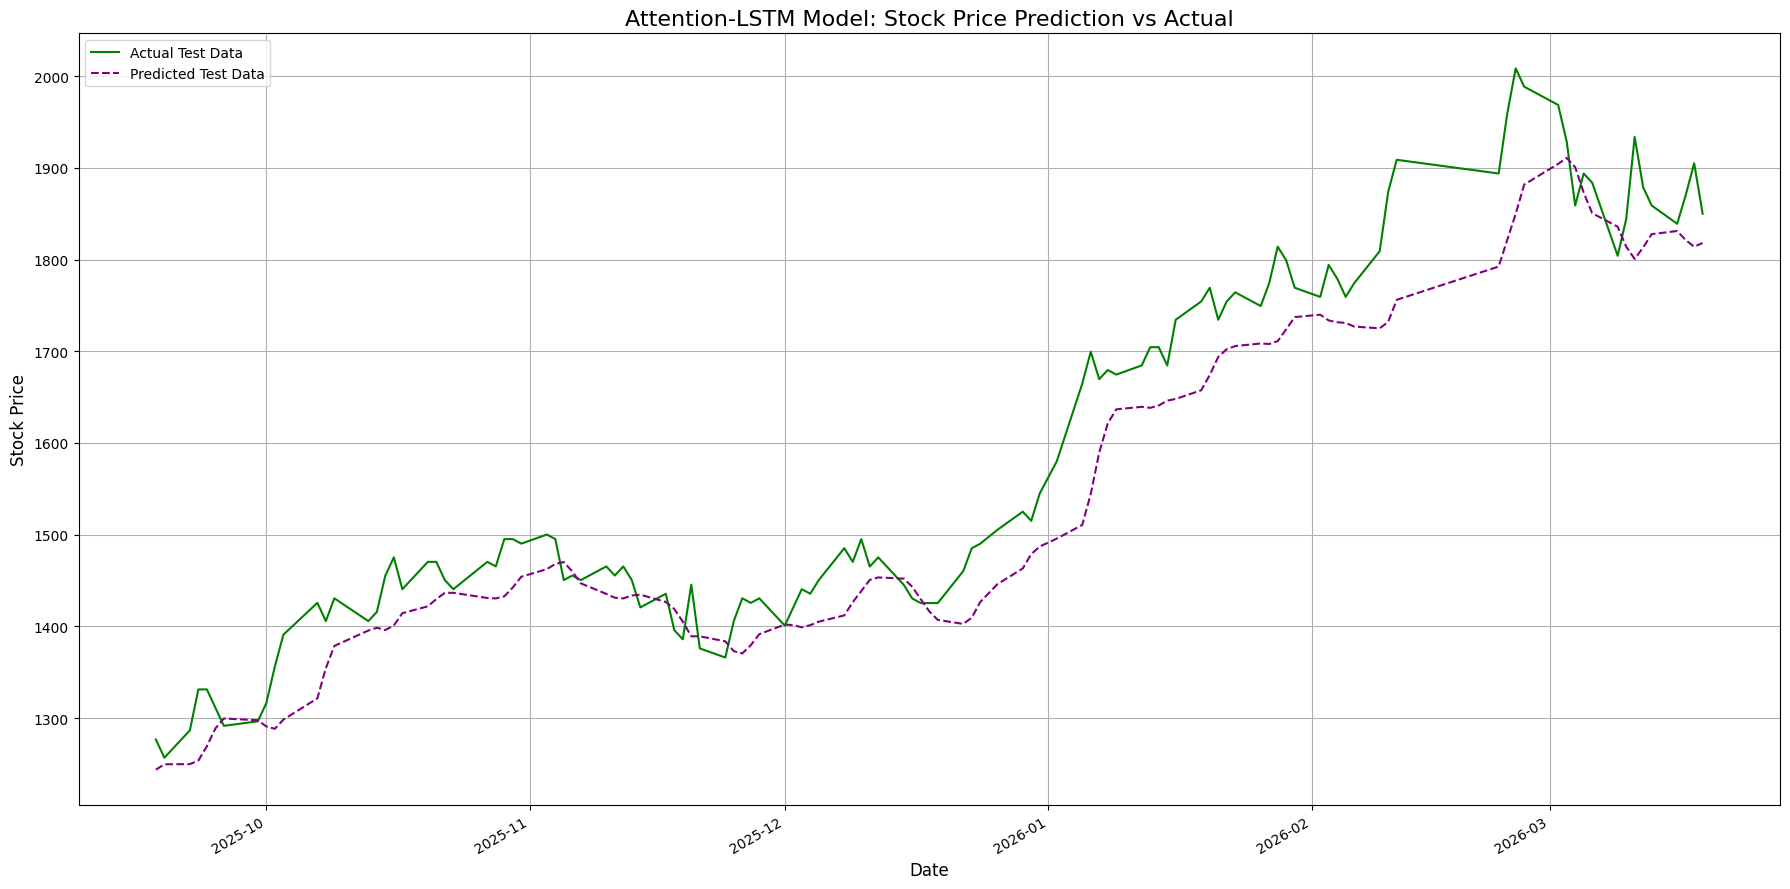

已成功繪製包含日期的股價預測圖。


In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# 確保必要變數存在，如果不存在則從先前的 CSV 重新載入
try:
    test_dates = stock_df.index[look_back + len(y_train_inverse):]
except NameError:
    print("正在重新載入資料以修復變數缺失問題...")
    # 假設 filename 變數也可能缺失，嘗試從檔案清單推斷或使用預設
    import os
    csv_files = [f for f in os.listdir('.') if f.endswith('_stock_data.csv')]
    if csv_files:
        stock_df = pd.read_csv(csv_files[0], index_col='Date', parse_dates=True)
        # 這裡假設之前的預處理邏輯，若環境完全清空，建議依序執行上方所有單元格
        print(f"已重新載入 {csv_files[0]}")
    else:
        print("找不到 CSV 檔案，請確保先執行下方的抓取資料單元格。")
print("test_dates lens: ",len(test_dates))

# 繪圖邏輯
fig, ax = plt.subplots(figsize=(18, 9))
test_dates = stock_df.index[look_back + len(y_train_inverse):]

ax.plot(test_dates, y_test_inverse, label='Actual Test Data', color='green', linewidth=1.5)
ax.plot(test_dates, test_predict_attention, label='Predicted Test Data', color='purple', linestyle='--', linewidth=1.5)

ax.set_title(f'Attention-LSTM Model: Stock Price Prediction vs Actual', fontsize=16)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Stock Price', fontsize=12)

fig.autofmt_xdate()
ax.legend(loc='upper left', fontsize=10)
ax.grid(True)

plt.tight_layout()
plt.show()
print('已成功繪製包含日期的股價預測圖。')

In [ ]:
import pandas as pd

recent_test_dates = pd.to_datetime(stock_df.index[look_back + len(y_train_inverse):])
result_length = min(len(recent_test_dates), len(y_test_inverse), len(test_predict_attention))

if result_length == 0:
    print("No test predictions available to display.")
else:
    recent_results = pd.DataFrame(
        {
            "Date": recent_test_dates[-result_length:].strftime("%Y-%m-%d"),
            "Actual": y_test_inverse[-result_length:].flatten(),
            "Predicted": test_predict_attention[-result_length:].flatten(),
        }
    )
    recent_results["AbsError"] = (recent_results["Predicted"] - recent_results["Actual"]).abs()

    print("近五天測試集預測 vs 實際：")
    print(
        recent_results.tail(5).to_string(
            index=False,
            float_format=lambda value: f"{value:.4f}",
        )
    )


## Evaluate Attention-LSTM Model Performance

### Subtask:
Calculate and report evaluation metrics, such as Root Mean Squared Error (RMSE), for both the training and testing predictions to quantitatively assess the performance of the Attention-LSTM model. This will provide a clear measure of accuracy.


The Root Mean Squared Error (RMSE) is a commonly used metric to measure the difference between values predicted by a model and the values observed. In the context of stock price prediction, RMSE quantifies the average magnitude of the errors made by the model in predicting stock prices. A lower RMSE value indicates a better fit of the model to the data. It is particularly useful because it gives a relatively high weight to large errors, meaning it is sensitive to outliers. The RMSE values for both the training and testing sets will indicate how well the Attention-LSTM model learned from the historical data and how well it generalizes to unseen data, respectively.

**Reasoning**:
Now that the explanation for RMSE has been provided, I will print the already calculated `train_rmse` and `test_rmse` values to report the evaluation metrics as required by the subtask.



In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

def mean_absolute_percentage_error(y_true, y_pred):
    # Avoid division by zero by replacing 0 actual values with a small epsilon or handling them
    # Here we'll just ignore cases where y_true is 0, which might not be ideal for all scenarios
    # For stock prices, 0 is unlikely, but good to be aware.
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Filter out zero values in y_true to prevent division by zero
    non_zero_mask = y_true != 0
    if not np.any(non_zero_mask):
        return np.nan # Or raise an error if no non-zero actual values

    return np.mean(np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])) * 100

# Calculate RMSE for training data
train_rmse = np.sqrt(mean_squared_error(y_train_inverse, train_predict_attention))

# Calculate MAE for training data
train_mae = mean_absolute_error(y_train_inverse, train_predict_attention)

# Calculate MAPE for training data
train_mape = mean_absolute_percentage_error(y_train_inverse, train_predict_attention)

# Calculate RMSE for testing data
test_rmse = np.sqrt(mean_squared_error(y_test_inverse, test_predict_attention))

# Calculate MAE for testing data
test_mae = mean_absolute_error(y_test_inverse, test_predict_attention)

# Calculate MAPE for testing data
test_mape = mean_absolute_percentage_error(y_test_inverse, test_predict_attention)

print("Attention-LSTM Model Performance Metrics:")
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Train MAE: {train_mae:.4f}")
print(f"Train MAPE: {train_mape:.2f}%")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Test MAPE: {test_mape:.2f}%")

Attention-LSTM Model Performance Metrics:
Train RMSE: 13.8795
Train MAE: 9.9566
Train MAPE: 2.68%
Test RMSE: 60.9182
Test MAE: 49.3266
Test MAPE: 3.03%
